# Data Loading and Bias Correction Application

> Fuente-González, M.

> This notebook documents the workflow for load the climate data and apply the bias correction "scaling" method.

The data to be used is contained in the *data* folder and contains daily precipitation (pr) and daily maximum temperature (tasmax) data for a subset region (latitude (39.8, 43) and longitude (-2.3, 3.6)) of the Mediterranean IPCC region, formatted as .rds files and intended for use within the Climate4R framework in R.

The dataset covers two 20-year periods:
* Historical period (1986–2005)

* Future climate projections corresponding to the scenario RCP8.5 and the Global Warming Level (GWL) of +2°C relative to pre-industrial conditions (2028-2047)

The files are provided as serialized R objects (.rds) to facilitate direct loading and analysis with Climate4R workflows.

The dataset includes:

- ERA5-Land

  Daily reanalysis data for the historical period (1986–2005):

  - **tasmax.era5.land.rds**: Daily maximum temperature from ERA5-Land.
  - **pr.era5.land.rds**: Daily precipitation from ERA5-Land.

- Simulation

    Daily climate projection data from a regional climate model simulation corresponding to a +2°C Global Warming Level (GWL).

    The example data provided in this repository correspond to one of the six simulations used in the associated study. This simulation was generated using the Regional Climate Model (RCM) RegCM, driven by the Global Climate Model (GCM) MPI-ESM-LR.

    Two versions of the data are provided:

    - RAW

        Original model outputs without bias adjustment.

        - **tasmax.hist.raw.rds**: Historical daily maximum temperature (1986–2005)

        - **tasmax.rcp8.5.raw.rds**: Future daily maximum temperature corresponding to the +2°C GWL (2028-2047)

        - **pr.hist.raw.rds**: Historical daily precipitation (1986–2005)

        - **pr.rcp8.5.raw.rds**: Future daily precipitation corresponding to the +2°C GWL (2028-2047)

    - Bias-adjusted (*ISIMIP3*)

        Model outputs bias-adjusted using the ISIMIP3 bias adjustment methodology.

        - **tasmax.hist.baisimip.rds**: Bias-adjusted historical daily maximum temperature (1986–2005)

        - **tasmax.rcp8.5.baisimip.rds**: Bias-adjusted future daily maximum temperature corresponding to the +2°C GWL (2028-2047)

        - **pr.hist.baisimip.rds**: Bias-adjusted historical daily precipitation (1986–2005)

        - **pr.rcp8.5.baisimip.rds**: Bias-adjusted future daily precipitation corresponding to the +2°C GWL (2028-2047)

In [ ]:
# It's necessary to install from remotes a version of the package transformeR that is compatible with the version of R you are using.
install.packages("remotes")
remotes::install_github("SantanderMetGroup/transformeR")

Installing package into ‘/home/vscode/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [5]:
library(loadeR)
library(transformeR)
library(downscaleR)
library(visualizeR)

### Data load

In [6]:
pr.era5 <- readRDS("data/pr.era5.land.rds")
tmax.era5 <- readRDS("data/tasmax.era5.land.rds")

pr.hist.raw <- readRDS("data/pr.hist.raw.rds")
tmax.hist.raw <- readRDS("data/tasmax.hist.raw.rds")

### Bias Adjustement

In [7]:
aux <- list()
for (i in 1:12){
print(i)
    mes <- subsetGrid(pr.hist.raw, season = i)
    mes.era5 <- subsetGrid(pr.era5, season = i)

    mes.bc <- biasCorrection(y=mes.era5, x=mes, newdata= mes, precipitation = TRUE, 
                    method="scaling", scaling.type="multiplicative")
    mes.bc$Dates$start <- as.character(mes.bc$Dates$start)
    mes.bc$Dates$end <- as.character(mes.bc$Dates$end)

    mes.bc.subset <- subsetGrid(mes.bc, season = i)
    aux[[i]] <- mes.bc.subset

}
pr.scaling <- redim(do.call(bindGrid, c(aux, list(dimension = "time", skip.temporal.check = TRUE))), drop=TRUE)
print("unido")

[1] 1


[2026-06-03 10:52:45.320464] Trying to determine the time zone...

[2026-06-03 10:52:45.3291] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone



[2026-06-03 10:52:45.525087] Trying to determine the time zone...

[2026-06-03 10:52:45.527934] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:52:45.685259] Trying to determine the time zone...

[2026-06-03 10:52:45.687201] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:52:46.679775] Argument precipitation is set as TRUE, please ensure that this matches your data.

[2026-06-03 10:52:47.351314] Number of windows considered: 1...

[2026-06-03 10:52:47.43053] Bias-correcting 1 members separately...

[2026-06-03 10:52:48.625871] Done.



[1] 2


[2026-06-03 10:52:48.665294] Trying to determine the time zone...

[2026-06-03 10:52:48.669468] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:52:48.806723] Trying to determine the time zone...

[2026-06-03 10:52:48.809432] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:52:48.9558] Trying to determine the time zone...

[2026-06-03 10:52:48.963642] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:52:49.94483] Argument precipitation is set as TRUE, please ensure that this matches your data.

[2026-06-03 10:52:50.534419] Number of windows considered: 1...

[2026-06-03 10:52:50.611628] Bias-correcting 1 members separately...

[2026-06-03 10:52:51.624042] Done.



...

[1] 11


[2026-06-03 10:53:14.667438] Trying to determine the time zone...

[2026-06-03 10:53:14.670644] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:14.805084] Trying to determine the time zone...

[2026-06-03 10:53:14.807595] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:14.943632] Trying to determine the time zone...

[2026-06-03 10:53:14.945539] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:15.881566] Argument precipitation is set as TRUE, please ensure that this matches your data.

[2026-06-03 10:53:16.428589] Number of windows considered: 1...

[2026-06-03 10:53:16.504205] Bias-correcting 1 members separately...

[2026-06-03 10:53:17.498835] Done.



[1] 12


[2026-06-03 10:53:17.544115] Trying to determine the time zone...

[2026-06-03 10:53:17.548402] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:17.697479] Trying to determine the time zone...

[2026-06-03 10:53:17.699883] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:17.834196] Trying to determine the time zone...

[2026-06-03 10:53:17.836077] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:18.654168] Argument precipitation is set as TRUE, please ensure that this matches your data.

[2026-06-03 10:53:19.080488] Number of windows considered: 1...

[2026-06-03 10:53:19.161113] Bias-correcting 1 members separately...

[2026-06-03 10:53:20.084494] Done.



[1] "unido"


[2026-06-03 10:53:20.465047] - Computing climatology...

[2026-06-03 10:53:20.504235] - Done.

[2026-06-03 10:53:20.517249] - Computing climatology...



[2026-06-03 10:53:20.574172] - Done.

[2026-06-03 10:53:20.610511] - Computing climatology...

[2026-06-03 10:53:20.646398] - Done.



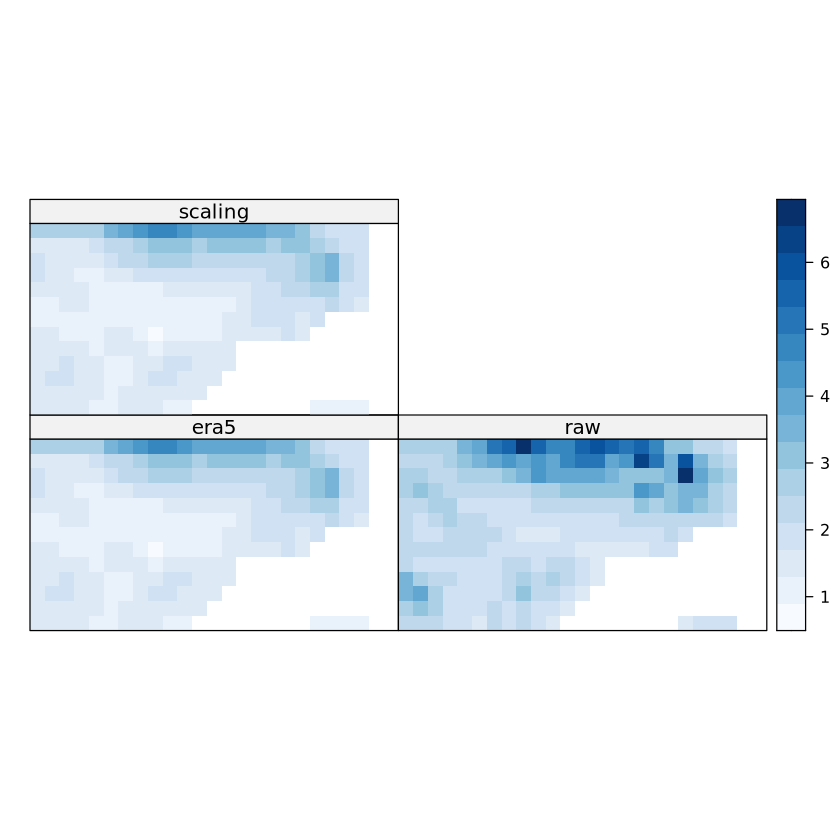

In [8]:
spatialPlot(makeMultiGrid(climatology(pr.era5), climatology(pr.hist.raw), climatology(pr.scaling), skip.temporal.check=TRUE), 
            color.theme="Blues", names.attr=c("era5", "raw", "scaling"))

In [9]:
aux <- list()

for (i in 1:12){
    print(i)
    mes <- subsetGrid(tmax.hist.raw, season = i)
    mes.era5 <- subsetGrid(tmax.era5, season = i)
    mes.bc <- biasCorrection(y=mes.era5, x=mes, newdata= mes, precipitation = FALSE, 
                    method="scaling", scaling.type="additive")
    mes.bc$Dates$start <- as.character(mes.bc$Dates$start)
    mes.bc$Dates$end <- as.character(mes.bc$Dates$end)
    mes.bc.subset <- subsetGrid(mes.bc, season=i)
    aux[[i]] <- mes.bc.subset

}

tmax.scaling <- redim(do.call(bindGrid, c(aux, list(dimension = "time", skip.temporal.check = TRUE))), drop=TRUE)
print("unido")

[1] 1


[2026-06-03 10:53:21.068869] Trying to determine the time zone...

[2026-06-03 10:53:21.07174] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone



[2026-06-03 10:53:21.21115] Trying to determine the time zone...

[2026-06-03 10:53:21.214721] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:21.348814] Trying to determine the time zone...

[2026-06-03 10:53:21.350616] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:22.041246] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-06-03 10:53:22.889318] Number of windows considered: 1...

[2026-06-03 10:53:22.979764] Bias-correcting 1 members separately...

[2026-06-03 10:53:24.017817] Done.



[1] 2


[2026-06-03 10:53:24.058912] Trying to determine the time zone...

[2026-06-03 10:53:24.062857] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:24.194818] Trying to determine the time zone...

[2026-06-03 10:53:24.196985] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:24.507729] Trying to determine the time zone...

[2026-06-03 10:53:24.511113] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:25.100716] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-06-03 10:53:25.809216] Number of windows considered: 1...

[2026-06-03 10:53:25.888077] Bias-correcting 1 members separately...

[2026-06-03 10:53:26.96593] Done.



...

[1] 11


[2026-06-03 10:53:49.904572] Trying to determine the time zone...

[2026-06-03 10:53:49.909753] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:50.039527] Trying to determine the time zone...

[2026-06-03 10:53:50.041408] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:50.168118] Trying to determine the time zone...

[2026-06-03 10:53:50.169982] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:51.124394] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-06-03 10:53:51.588503] Number of windows considered: 1...

[2026-06-03 10:53:51.66562] Bias-correcting 1 members separately...

[2026-06-03 10:53:52.52797] Done.



[1] 12


[2026-06-03 10:53:52.559966] Trying to determine the time zone...

[2026-06-03 10:53:52.562973] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:52.697014] Trying to determine the time zone...

[2026-06-03 10:53:52.69887] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:52.841394] Trying to determine the time zone...

[2026-06-03 10:53:52.843815] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-06-03 10:53:53.553734] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-06-03 10:53:54.091895] Number of windows considered: 1...

[2026-06-03 10:53:54.166669] Bias-correcting 1 members separately...

[2026-06-03 10:53:54.977071] Done.



[1] "unido"


[2026-06-03 10:53:55.317329] - Computing climatology...



[2026-06-03 10:53:55.380066] - Done.

[2026-06-03 10:53:55.398568] - Computing climatology...

[2026-06-03 10:53:55.433542] - Done.

[2026-06-03 10:53:55.475908] - Computing climatology...

[2026-06-03 10:53:55.516557] - Done.



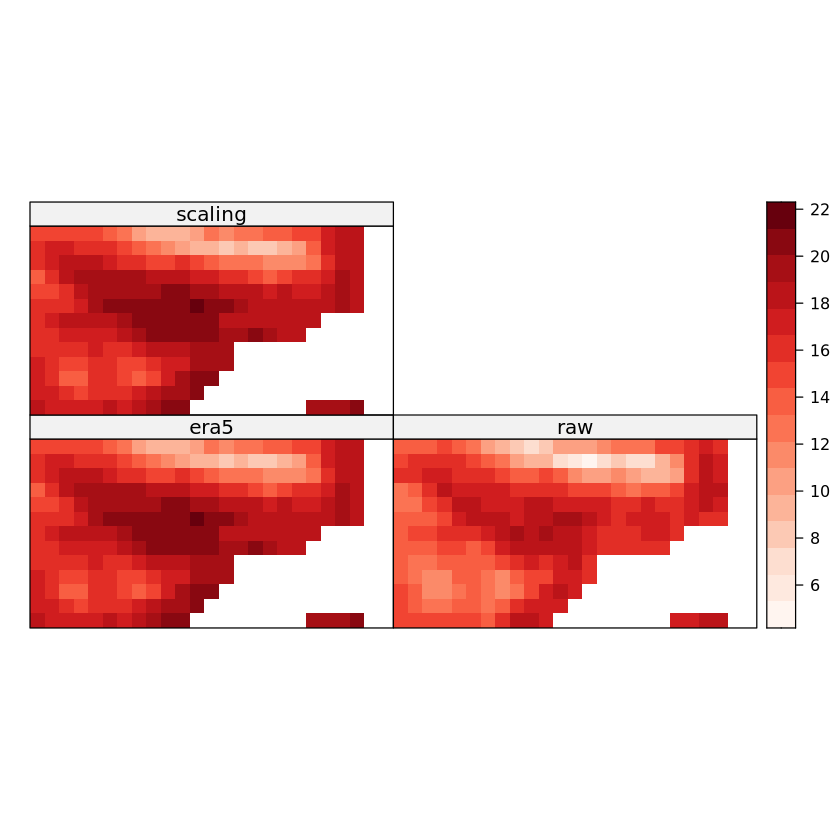

In [10]:
spatialPlot(makeMultiGrid(climatology(tmax.era5), climatology(tmax.hist.raw), climatology(tmax.scaling), skip.temporal.check=TRUE), 
            color.theme="Reds", names.attr=c("era5", "raw", "scaling"))